In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np

from student_client import create_student_gym_env

env = create_student_gym_env(user_token='SERgio26735540')
env.reset()

2026-03-02 22:51:28,611 - dotenv.main - WARNING - python-dotenv could not parse statement starting at line 2
2026-03-02 22:51:28,612 - student_client.student_gym_env - WARNING - No .env file found and no explicit parameters provided. Using default values. For better setup, create a .env file with:
SERVER_URL=http://rlchallenge.orailix.com
USER_TOKEN=student_user
ENV_TYPE=DegradationEnv
MAX_STEPS_PER_EPISODE=1000
AUTO_RESET=True
TIMEOUT=30.0
2026-03-02 22:51:28,663 - student_client.student_gym_env - INFO - Client is up to date (version 0.4)
2026-03-02 22:51:28,684 - student_client.student_gym_env - INFO - Created new session: f66dabe1-dc8c-4270-8fd4-f3a77e0799f7
2026-03-02 22:51:29,852 - student_client.student_gym_env - INFO - Created new episode: 48d2a34c-7036-4fa5-84ce-2b071f5f71e3
2026-03-02 22:51:29,856 - student_client.student_gym_env - INFO - StudentGymEnv initialized with episode 48d2a34c-7036-4fa5-84ce-2b071f5f71e3
2026-03-02 22:51:31,029 - student_client.student_gym_env - INFO 

(array([7.9645404e+02, 1.9392914e+04, 3.3555664e+02, 1.1197432e+03,
        3.7199318e-01, 1.3676350e+06, 3.9563218e+03, 0.0000000e+00,
        9.7298269e+00], dtype=float32),
 {'step': 0,
  'episode_id': '509f5b43-7a28-440a-be08-1fed2f79320c',
  'terminated': False,
  'truncated': False})

In [5]:
# Reset environment to get initial observation
obs, info = env.reset()
print(f"📋 Starting episode {info.get('episode_id', 'unknown')}")

obs.shape, info

2026-03-02 22:51:59,856 - student_client.student_gym_env - INFO - 🔄 Episode ID changed from 509f5b43-7a28-440a-be08-1fed2f79320c to e8cc40df-35ae-4040-8dcc-d947b549d4e2 (old episode had steps)
2026-03-02 22:51:59,857 - student_client.student_gym_env - INFO - Episode e8cc40df-35ae-4040-8dcc-d947b549d4e2 reset successfully


📋 Starting episode e8cc40df-35ae-4040-8dcc-d947b549d4e2


((9,),
 {'step': 0,
  'episode_id': 'e8cc40df-35ae-4040-8dcc-d947b549d4e2',
  'terminated': False,
  'truncated': False})

In [6]:
# Initialize data collection arrays
observations = []
actions = []
rewards = []
total_timesteps = 0

for step in range(50):

    # Choose a random action (0=do nothing, 1=repair, 2=sell)
    action = env.action_space.sample()
    print(action)

    # Take step in environment
    obs_result, reward, terminated, truncated, info = env.step(
        action=action,
    )

    print(f'obs_result: {obs_result.shape}')

    observations.append(obs_result)
    actions.append(action)

    rewards.append(reward)

    # Update total timesteps - server advances by step_size but returns only final observation
    total_timesteps = info['step']

    # Print progress every step
    if step % 1 == 0:
        print(f" Step {total_timesteps}: Reward={reward:.2f}, Total={sum(rewards):.2f}")

    # Check if episode ended
    if terminated or truncated:
        print(f"🏁 Episode ended at step {total_timesteps} with reward={reward:.2f}")
        break


# Print summary statistics
total_reward = sum(rewards)
print(f"\n Episode Summary:")
print(f"   Total Steps: {len(actions)}")
print(f"   Total Reward: {total_reward:.2f}")
print(f"   Actions Taken: {len([a for a in actions if a == 1])} repairs, {len([a for a in actions if a == 2])} sell")

2
Episode e8cc40df-35ae-4040-8dcc-d947b549d4e2 reached termination state, reason: sold
obs_result: (1, 9)
 Step 1: Reward=150.00, Total=150.00
🏁 Episode ended at step 1 with reward=150.00

 Episode Summary:
   Total Steps: 1
   Total Reward: 150.00
   Actions Taken: 0 repairs, 1 sell


In [7]:
# Finish episode
env.close()

2026-03-02 22:52:09,958 - student_client.student_gym_env - INFO - Closed environment e8cc40df-35ae-4040-8dcc-d947b549d4e2


In [8]:
len(observations), len(actions)

(1, 1)

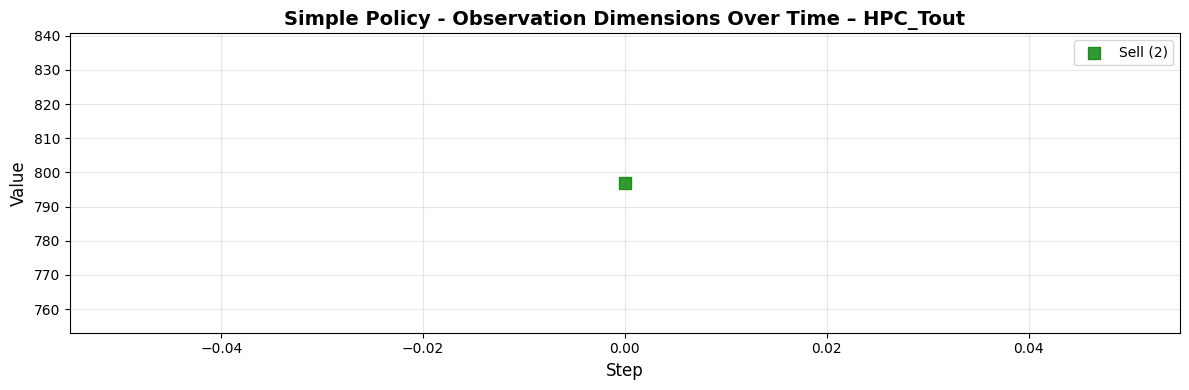

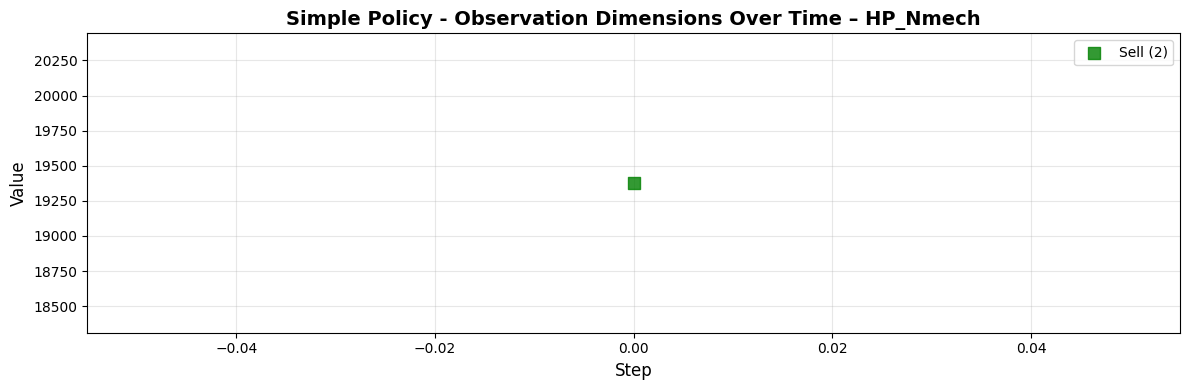

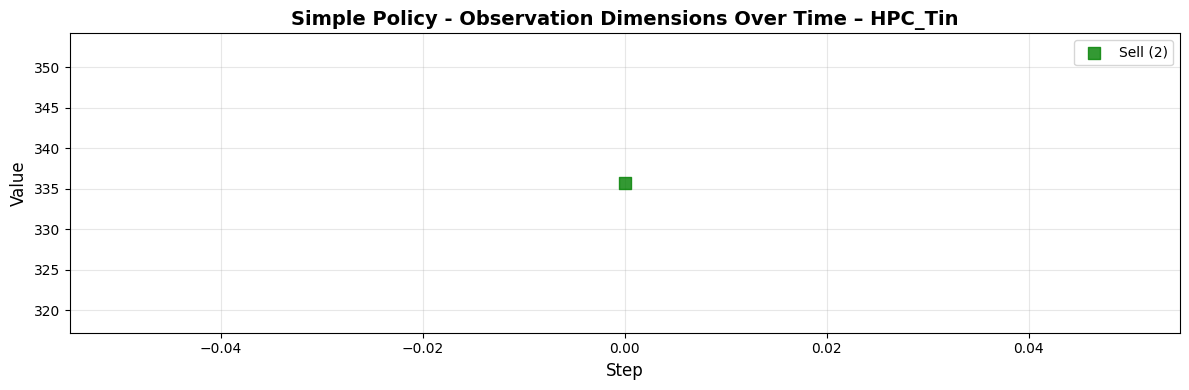

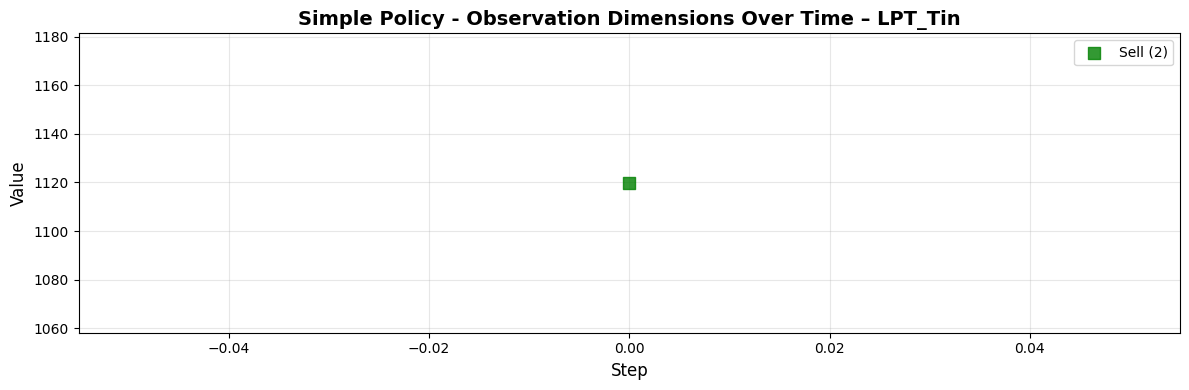

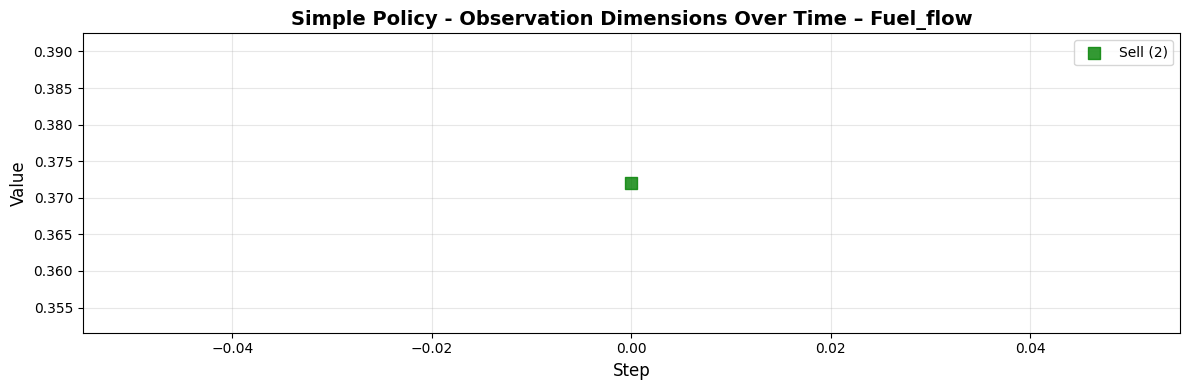

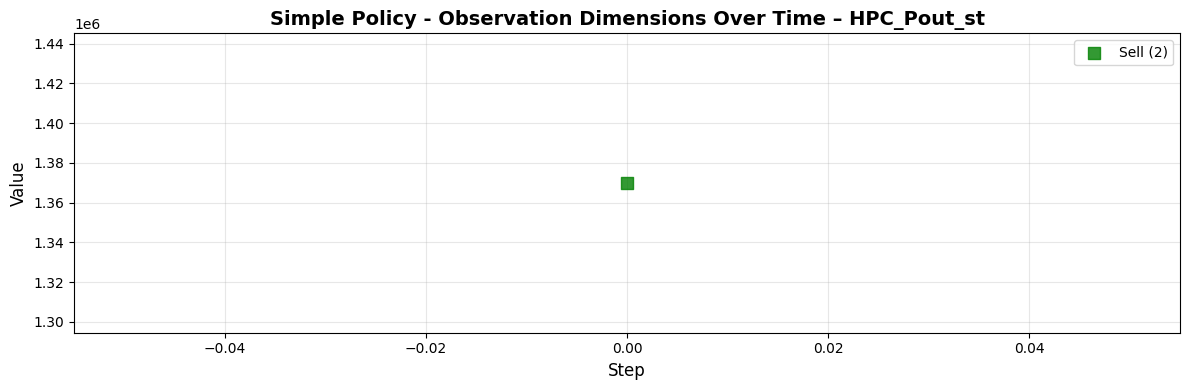

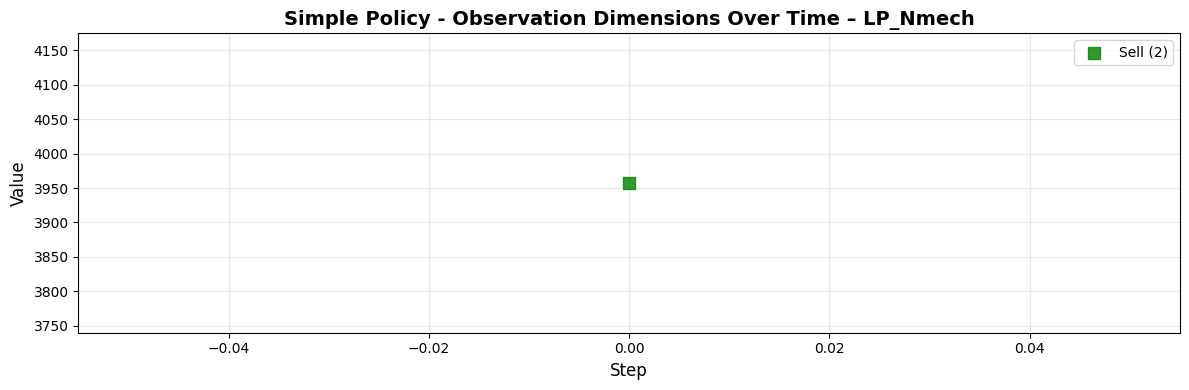

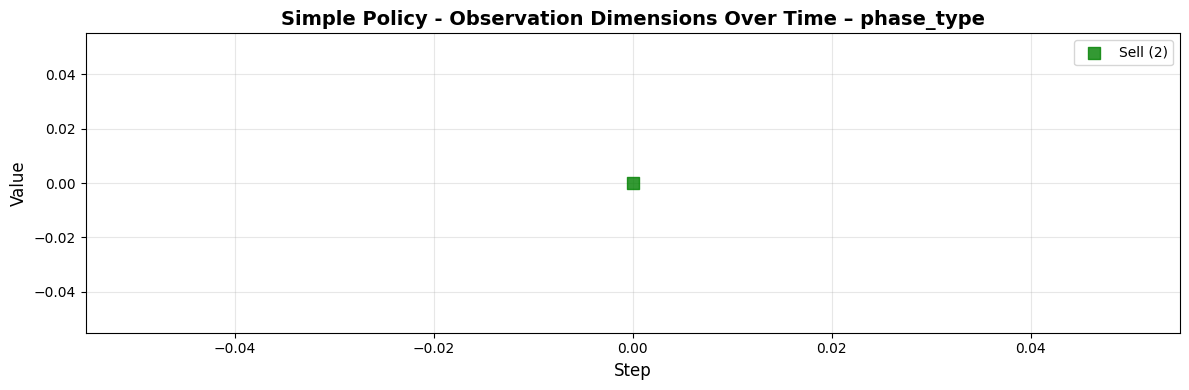

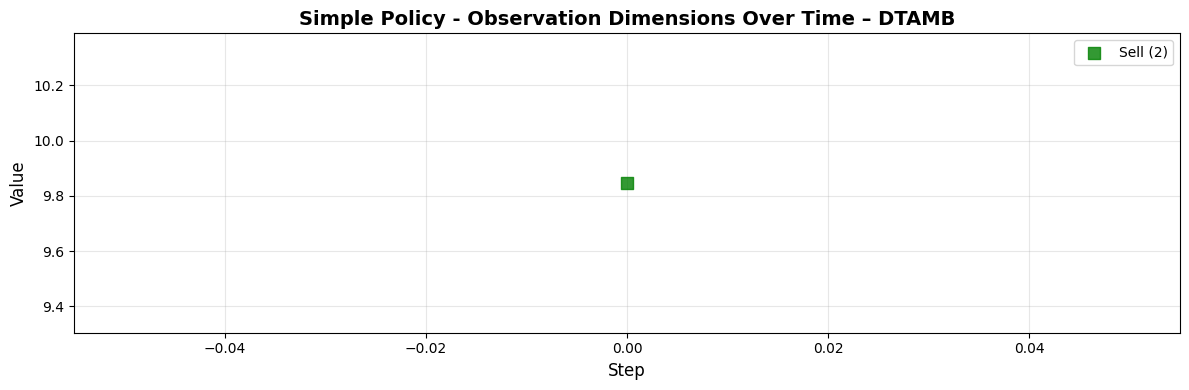

In [9]:
from student_client.plotting import plot_observations


plot_observations(
        observations=observations,
        actions=actions,
        title="Simple Policy - Observation Dimensions Over Time"
    )

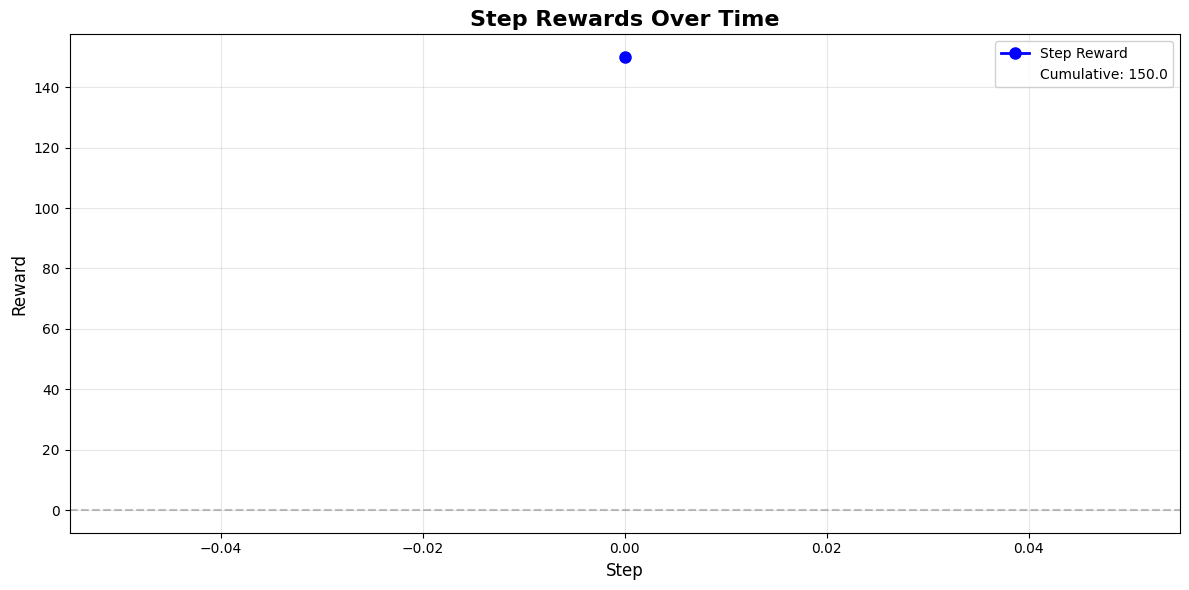

📊 Reward Statistics:
   Total Steps: 1
   Total Reward: 150.00
   Average Reward: 150.00
   Max Reward: 150.00
   Min Reward: 150.00


In [10]:
from student_client.plotting import plot_rewards

plot_rewards(rewards=rewards)